# **Multi-Asset Portfolio Performance, Risk & Attribution**

**FINM3422 — Assessment 2 - Group 8**

# **1.0 Introduction**

This report presents a performance, risk, and attribution analysis of a large Australian superannuation fund investing across five asset-class sleeves: Australian Equities (AUS EQ), International Equities (INTL EQ), Bonds / Fixed Income, Real Estate (RE), and Private Equity / Venture Capital (PE/VC). Each sleeve is managed by an external manager and evaluated against a designated benchmark index.

The analysis covers the 10-year period from January 2016 to December 2025 using monthly return data, assessed against a composite benchmark constructed from Strategic Asset Allocation (SAA) weights. Performance is evaluated at both sleeve and total fund level, with APRA-inspired supervisory checks applied to assess long-run return adequacy, volatility, drawdown resilience, and stress scenario behaviour. Active return is further decomposed using the Brinson attribution framework to identify the  contribution of allocation and selection decisions across all five sleeves.

# **2.0 Data Overview**

The dataset consists of monthly return series for five asset-class sleeves, 
covering both manager returns and corresponding benchmark indices over the 
period January 2016 to December 2025 (120 observations). Benchmarks reflect 
industry-standard proxies: the S&P/ASX 200 for AUS EQ, MSCI World 
ex-Australia for INTL EQ, a Bloomberg AusBond proxy for Bonds, an A-REIT 
proxy for Real Estate, and a stylised synthetic benchmark for PE/VC. A 
risk-free rate proxy is included for Sharpe ratio calculations.

All data is loaded via a centralised pipeline that enforces a DatetimeIndex, 
validates monthly frequency, confirms full manager-benchmark date alignment, 
and checks for missing values prior to analysis.

Two sets of weights are used throughout — the Tactical Asset Allocation (TAA), 
reflecting the fund's current active positioning, and the Strategic Asset 
Allocation (SAA), representing the long-term policy benchmark. Both are held 
constant across the analysis period:

| Asset Class            | TAA Weight | SAA Weight |
|------------------------|------------|------------|
| Australian Equities    | 35%        | 40%        |
| International Equities | 35%        | 30%        |
| Bonds                  | 15%        | 20%        |
| Real Estate            | 5%         | 5%         |
| PE/VC                  | 10%        | 5%         |

### 2.1 Environment Info, Imports and Confit

In [1]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

sys.path.append("../src")

from data_loader import load_all_data, SLEEVE_LABELS, TAA_WEIGHTS, SAA_WEIGHTS
from performance import (all_sleeves_summary, sleeve_summary, annualised_return, annualised_volatility, max_drawdown, apra_checks, equity_crash, bond_yield_spike, display_summary_tables, fund_vs_benchmark)
from attribution import brinson_attribution
from charts import (plot_sleeve_wealth_index, plot_sleeve_vs_benchmark, plot_fund_vs_benchmark, plot_sharpe_bar, plot_ir_bar, plot_apra_drawdown_threshold, plot_attribution)

print(sys.version)
print("pandas:", pd.__version__, "numpy:", np.__version__)
pd.set_option("display.float_format", "{:.4f}".format)

3.13.2 (v3.13.2:4f8bb3947cf, Feb  4 2025, 11:51:10) [Clang 15.0.0 (clang-1500.3.9.4)]
pandas: 2.2.3 numpy: 2.2.3


### 2.2 Parameters and Paths

In [2]:
# Base path to data folder
BASE_path = "/Users/ameliaperry/Desktop/BAFE/FINM3422/python case/FINM3422-Group-8-Task-2-1/data/"

# TAA and SAA weights loaded from data_loader
taa_weights = pd.Series(TAA_WEIGHTS)
saa_weights = pd.Series(SAA_WEIGHTS)

### 2.3 Data Load and Sanity Check

In [3]:
# Load and Validate Data
data = load_all_data(BASE_path)

df_managers   = data["managers"]
df_benchmarks = data["benchmarks"]
df_rf         = data["rf"]
# Sanity Checks
print("Any nulls in benchmarks?", df_benchmarks.isna().sum().sum())
print("Any nulls in managers?", df_managers.isna().sum().sum())
print("Dates aligned?", df_benchmarks.index.equals(df_managers.index))
print("Monotonic dates?", df_benchmarks.index.is_monotonic_increasing)

display(df_managers.head())
display(df_benchmarks.head())
display(df_rf.head()) 

Data loaded and validated successfully.
   Date range : 2016-01-31 to 2025-12-31
   Months     : 120
   Sleeves    : ['aus_eq', 'intl_eq', 'bonds', 're', 'pevc']
Any nulls in benchmarks? 0
Any nulls in managers? 0
Dates aligned? True
Monotonic dates? True


,aus_eq,intl_eq,bonds,re,pevc
Date,,,,,
2016-01-31,-0.0364,0.0083,0.0148,-0.0099,-0.0117
2016-02-29,0.0461,0.0232,0.0049,0.0332,-0.0315
2016-03-31,0.0377,-0.0149,0.0016,0.0319,0.0098
2016-04-30,0.0382,0.0108,-0.0012,0.0466,-0.0547
2016-05-31,-0.0316,0.0752,0.0209,0.0489,0.0013


,aus_eq,intl_eq,bonds,re,pevc
Date,,,,,
2016-01-31,-0.0249,0.0032,0.0143,-0.0002,-0.0119
2016-02-29,0.0414,0.0062,0.0087,0.0312,-0.0336
2016-03-31,0.0333,-0.0083,-0.0013,0.0271,0.0146
2016-04-30,0.0241,0.0144,-0.0051,0.0198,-0.0585
2016-05-31,-0.0270,0.0743,0.0206,0.0358,0.0152


Date
2016-01-31   0.0025
2016-02-29   0.0025
2016-03-31   0.0025
2016-04-30   0.0025
2016-05-31   0.0025
Freq: ME, Name: rf, dtype: float64

# **3.0 Performance and Risk Analysis**

### 3.1 Methodology

Performance metrics are calculated using monthly returns and annualised 
geometrically to capture the compound growth rate. Together, these metrics 
provide a comprehensive view of both absolute and relative performance, 
covering return adequacy, risk efficiency, and downside resilience.

**Annualised Return** — geometric growth rate of monthly returns:
$$R_{\text{ann}} = \left(\prod_{t=1}^{n}(1 + r_t)\right)^{12/n} - 1$$
- $r_t$: monthly return in month $t$, $n$: number of monthly observations

**Annualised Volatility** — monthly standard deviation scaled annually:
$$\sigma_{\text{ann}} = \sigma_{\text{monthly}} \times \sqrt{12}$$

**Sharpe Ratio** — excess return above the risk-free rate per unit of total risk:
$$\text{Sharpe} = \frac{R_{\text{ann}} - R_{f,\text{ann}}}{\sigma_{\text{ann}}}$$
- $R_{f,\text{ann}}$: annualised risk-free rate

**Tracking Error** — annualised volatility of monthly active returns:
$$TE = \sigma(r_P - r_B) \times \sqrt{12}$$
- $r_P - r_B$: monthly active return (manager minus benchmark)

**Information Ratio** — active return per unit of active risk:
$$IR = \frac{R_P - R_B}{TE}$$

**Maximum Drawdown** — largest peak-to-trough decline in cumulative wealth:
$$MDD = \min_t \left(\frac{W_t - \max(W)}{\max(W)}\right)$$
- $W_t$: cumulative wealth at time $t$


### 3.2 Results Summary

In [4]:
summary = all_sleeves_summary(df_managers, df_benchmarks, df_rf)
display_summary_tables(summary)

Table 1: Performance & Risk Summary (%)


,Annualised Return (Manager),Annualised Return (Benchmark),Annualised Volatility,Tracking Error,Maximum Drawdown (Manager),Maximum Drawdown (Benchmark)
aus_eq,6.91%,5.88%,14.16%,4.40%,-24.63%,-27.65%
intl_eq,15.57%,13.94%,11.96%,2.57%,-16.49%,-16.42%
bonds,3.02%,1.89%,4.46%,0.94%,-11.35%,-13.94%
re,10.84%,8.03%,18.72%,7.10%,-28.69%,-37.41%
pevc,10.24%,9.38%,10.86%,2.08%,-11.62%,-11.95%


Table 2: Ratios


,Sharpe Ratio,Information Ratio
aus_eq,0.27,0.23
intl_eq,1.05,0.64
bonds,-0.00,1.21
re,0.42,0.39
pevc,0.66,0.41


Accross the five sleeves, manager returns were consistently above the relative benchmarks, suggesting overall positive active management over the full 10-year sample period. However, the level and consistency of outperformance varied significantly between sleeves. 

**Australian Equities** showed modest outperformance (6.91% vs 5.88%), with a low Sharpe index of 0.27, reflective of high volatility compared to return. Maximum drawdown of -24.63% is consistent with the significant Australian equity market fluctuations over this time. 

**International Equities** performed the strongest on both an absolute and risk-adjusted returns basis. The manager delivered 15.57% annualsied against a 13.94% benchmark while maintaining the lowest volatility of the equity sleeves at 11.96%. The Sharpe ratio of 1.05 is the only sleeve to achieve above 1.0, indicating genuine risk-adjusted perfromance. The low tracking error of 2.57% alongside an IR of 0.64 suggests the manager was disciplined and actve by consistently added value without taking large bets.

**Bonds** produced near-zero risk-adjusted returns, with the Sharpe Ratio of -0.00 reflecting that the return of 3.02% was only minorly above the risk-free rate over this period. This was to be expected, as the firs half of the sample period's low-yield environment compressed bond yields. The 2022 rate hiking cycle generated significant mark-to-market losses, reflectd in the -11.35 maximum drawdown. Despite this, the bonds manager produced the highest IR of 1.21 across all sleeves, outfperforming the benchmark by 1.13% with a tracking error of only 0.94%. Even though bonds achieved the lowest return, the manager for this sleeve was the most effective by adding substantial value relative to the benchmark despite the challenging rate environment.

**Real Estate** produced the second highest manager return at 10.84% value versus the benchmark of 8.03%, an outperformance of 2.81%. However, this also had the highest volatility of 18.72% and largest manager drawdown of -28.69% across akk sleeves. The tracking error almost three times larger than international equities of 7.10% indicates the manager took significant active risk to generate this return, also reflected in the relatively low IR of 0.39. The benchmarks lower drawdown of -37.41% suggests the manager navigated downside risk during periods of market stress, which is the primary source of outperformance. 

**PE/VC** delivered 10.24% annualised return with the lowest volatility of the sleeves at 10.86% and the second highest Sharpe ratio of 0.66. This smooth return profile is typical of private market assets, where valuations are reported infrequently and do not always accurately capture short-term market movements. The low tracking error of 2.08% and IR of 0.41 suggest steady, consistent outperformance rather than large active tilts.


### 3.3 Visualisations

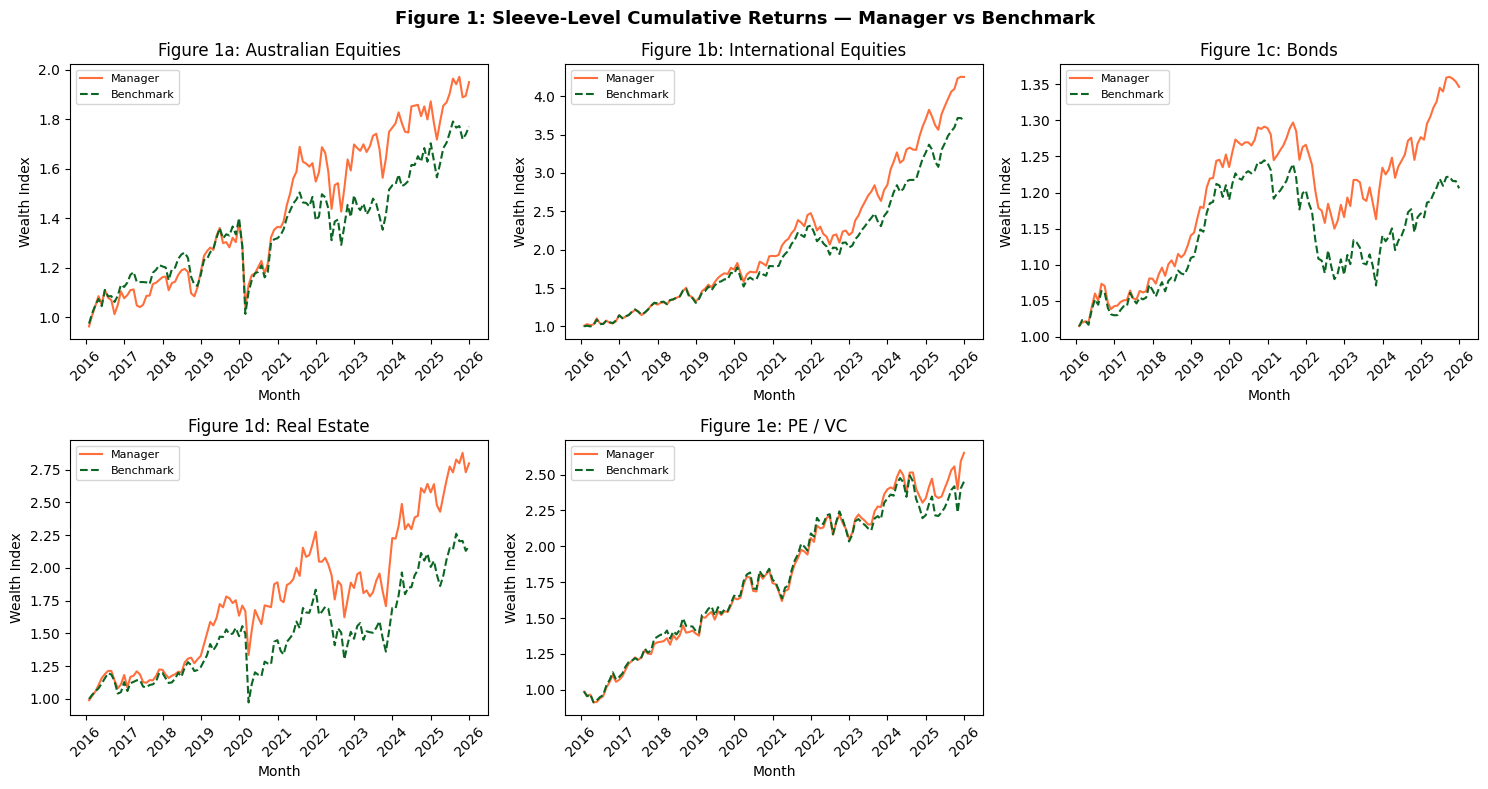

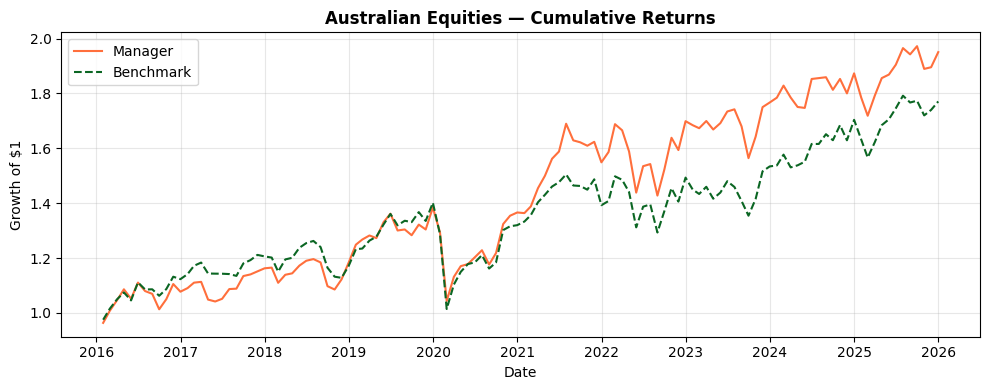

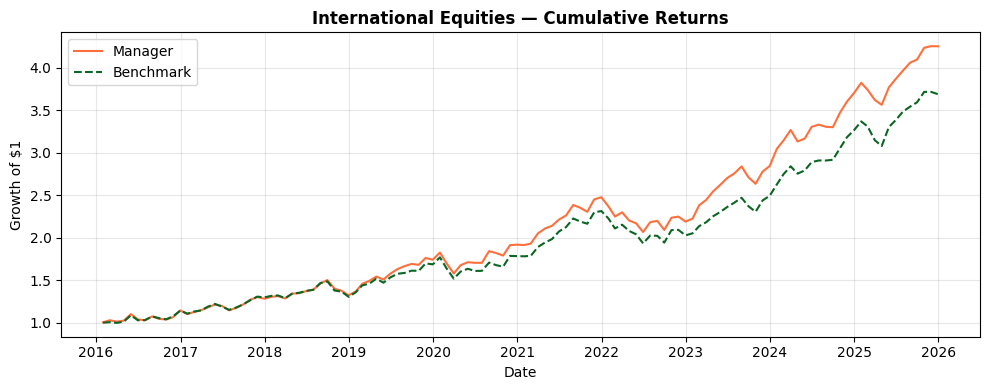

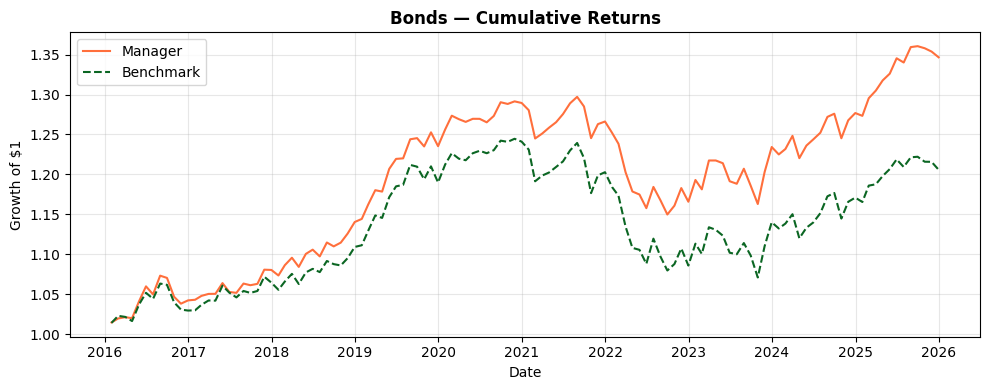

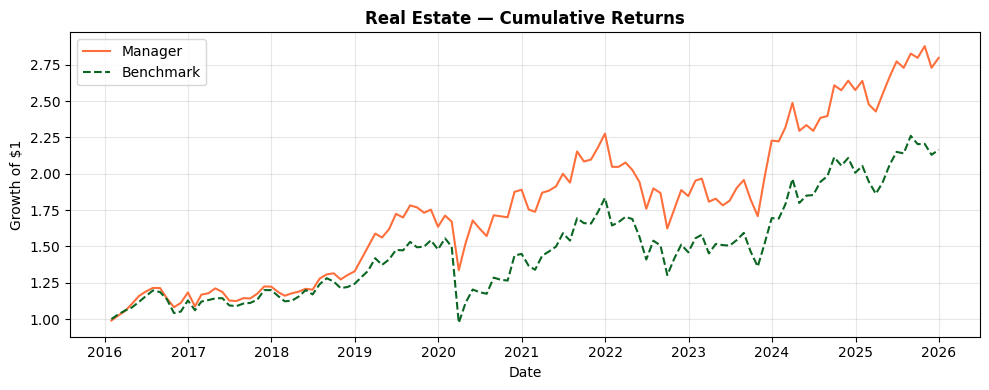

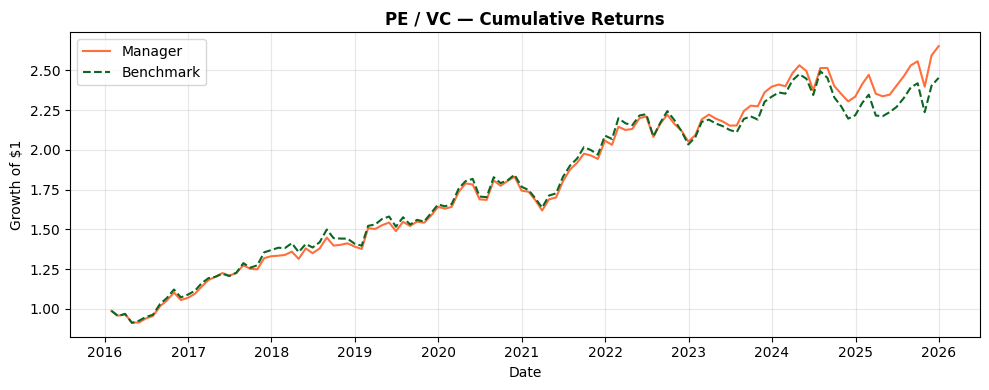

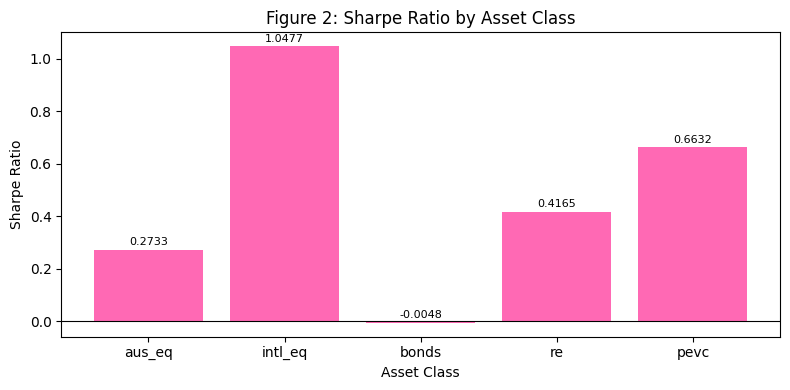

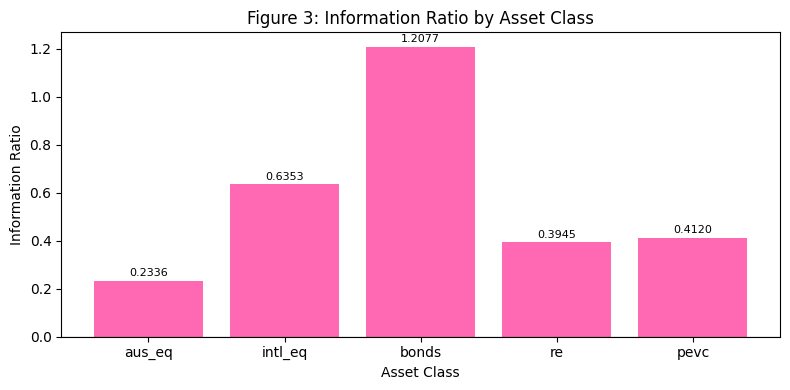

In [5]:
plot_sleeve_wealth_index(df_managers, df_benchmarks, SLEEVE_LABELS)

for sleeve in df_managers.columns:
    wealth_mgr = (1 + df_managers[sleeve]).cumprod()
    wealth_bm  = (1 + df_benchmarks[sleeve]).cumprod()
    plt.figure(figsize=(10, 4))
    plt.plot(wealth_mgr, label="Manager", color="#FF6F3C")
    plt.plot(wealth_bm,  label="Benchmark", color="#0B6623", linestyle="--")
    plt.title(SLEEVE_LABELS[sleeve] + " — Cumulative Returns", fontweight="bold")
    plt.xlabel("Date")
    plt.ylabel("Growth of $1")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_sharpe_bar(summary.T)
plot_ir_bar(summary.T)

The cumulative return charts reinforce the summary table findings and provide further context on the timing and consistency of outperformance.

**Equity sleeves (AUS EQ & INTL EQ)** both show a sharp drawdown in early 2020 consistent with the COVID-19 shock, followed by a quicker recovery by the manager than the benchmark. INTL EQ shows the largest divergence, with the manager accelerating well above the benchmark from 2023 onwards to reach $4.20 versus $3.70 by 2026, the widest  terminal gap of all five sleeves and the primary driver of its 15.57% annualised return.

**Real Estate** experienced the most severe benchmark drawdown in 2020, falling back to approximately $1.00 while the manager held above $1.50. This justifies the large difference in maximum drawdown (-28.69% vs -37.41%). Both recovered strongly after 2021, with the manager sustaining a wide and growing gap through to 2026.

**Bonds and PE/VC** both show smooth, steady growth with the manager's returns consistently above the benchmark throughout the entire period and no visible severe drawdowns. The Bonds gap widens significantly after 2022, consistent with the manager navigating the rate hiking cycle more effectively than the benchmark. PE/VC follows the benchmark for most of the period before a divergence of approximately $0.25 emerges from 2024 onwards.

**Sharpe and IR charts** confirm that International Equities and PE/VC are the strongest risk-adjusted performers on both measures, while AUS EQ is low on both. The Bonds IR standing well above all other sleeves despite its near-zero Sharpe highlights that absolute and relative performance metrics are highly relevant on the manager's skill.

# **4.0 APRA-Inspired Performance and Risk Checks**

### 4.1 Methodology

APRA-inspired checks are applied to the total fund return, constructed using TAA weights and manager returns. Three simplified supervisory checks are adopted, alongside two stress scenarios to assess portfolio resilience under adverse conditions:

1. **Long-run return vs objective (CPI + 3.5%)** — ensures the fund delivers sufficient real returns to meet members' retirement outcomes over time
2. **Annualised volatility vs risk limit (10%)** — confirms the fund is not assuming excessive risk relative to a balanced superannuation mandate
3. **Maximum drawdown vs threshold (-25%)** — identifies whether the fund experienced an unacceptable peak-to-trough loss that would attract regulatory scrutiny

Two shock scenarios are then applied to a single month's returns to test vulnerability to sudden adverse market events: an equity crash (-20% to AUS EQ and INTL EQ) and a bond yield spike (+150bps, implying  approximately -5% on bonds with spillover effects across other asset classes).

These checks are educational approximations designed to capture the spirit of APRA's long-term performance and risk oversight rather than reproduce the requirements of Prudential Standard SPS 530.

### 4.2 TAA Weights and Total Fund Return

In [6]:
df_fund_monthly = df_managers.mul(taa_weights).sum(axis=1)

df_benchmark_monthly = df_benchmarks.mul(saa_weights).sum(axis=1)

print("Fund monthly returns (first 5):")
display(df_fund_monthly.head())

Fund monthly returns (first 5):


Date
2016-01-31   -0.0093
2016-02-29    0.0235
2016-03-31    0.0108
2016-04-30    0.0138
2016-05-31    0.0210
Freq: ME, dtype: float64

### 4.3 APRA Checks

In [8]:
apra_results = apra_checks(df_fund_monthly)
print("Table 3: APRA Performance & Risk Checks:")
display(apra_results)

Table 3: APRA Performance & Risk Checks:


,Fund Value,Threshold,Pass / Fail
Long-Run Return vs Objective (CPI + 3.5%),10.38%,6.00%,Pass
Annualised Volatility vs Risk Limit (10%),6.85%,10.00%,Pass
Maximum Drawdown vs Threshold (-25%),-9.22%,-25.00%,Pass


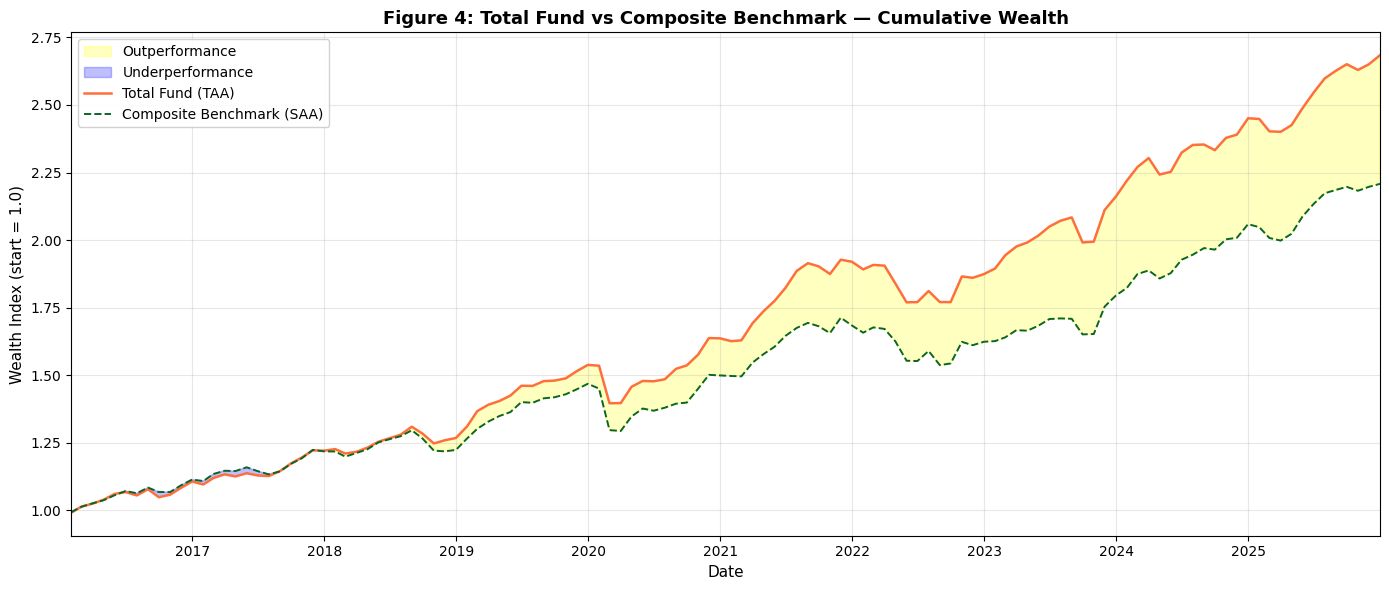

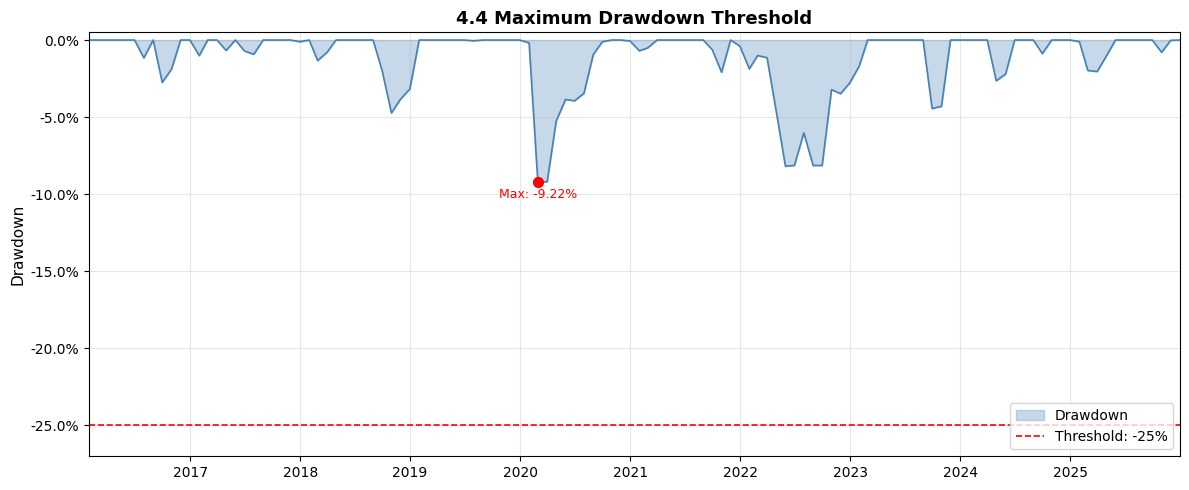

In [9]:
plot_fund_vs_benchmark(df_fund_monthly, df_benchmark_monthly)
plot_apra_drawdown_threshold(df_fund_monthly, threshold=-0.25)

The fund passed all three APRA-inspired checks over the full sample period. The long-run return of 10.38% greatly exceed the CPI + 3.5% target of 6.00%, suggesting the fund delivered strong real returns well above what would be needed to support the business's retirement payment obligations. This margin of 4.38% above the target means the fund is not just relying on favourable short-term conditions. 

The maximum drawdown of -9.22% passed the -25% threshold easily. This is a relatively shallow drawdown for a growth-oriented multi-asset fund that included the COVID-19 market disruption and 2022 rate-hiking cycle. This is particularly significant given that the Real Estate sleeve alone experienced a maximum drawdown of -28.69%, yet the fund-level drawdown remained within threshold. This demonstrates how  diversifications across five asset classes contributed to containing the total fund's decline in these periods.

Annualised volatility of 6.85% sits within the 8-12% band typical of a balanced superannuation fund, and below the 10% limit, placing this fund in the defensive category. This is lower than to be expected given the 70% combined equity weight, and reflects the cushioning effect of the Bonds and PE/VC sleeves on the overall portfolio risk through diversification. 

### 4.4 Shock Scenario A

Simulates a simultaneous -20% monthly return in both AUS EQ and INTL EQ, consistent with severe historical equity dislocations such as the GFC and COVID-19, while all other sleeves retain normal 
returns. Given the combined 70% TAA weight in equities, this represents the most significant single risk event the fund could face.

In [10]:
print("Table 4: Shock Scenario A — Equity Crash")
display(equity_crash(df_managers, TAA_WEIGHTS))

Table 4: Shock Scenario A — Equity Crash


,Scenario,AUS EQ Return,INTL EQ Return,Portfolio Return,Impact vs Normal
0,Normal (baseline),-4.20%,3.38%,-0.80%,-
1,Equity Crash (-20%),-24.20%,-16.62%,-14.80%,-14.00%


A simultaneous -20% monthly shock to both Australian and International Equities produces a portfolio return of -13.73% for that month, compared to a normal return of 1.27%, a 15.01% reduction. This is a direct consequence of the fund's 70% combined Equities TAA weight, that means equity market shocks have a proportionally large impact on the total fund. The defensive sleeves (Bonds, RE, and PE/VC) provide only a partial buffer given their combined TAA weight of just 30%, meaning a synchronised equity shock of this magnitude would overwhelm their diversification benefit. This structural risk means the fund would experience significant short-term losses in a severe equity market disruption.

### 4.5 Shock Scenario B - Bond Yield Spike

simulates a +150 basis point bond yield spike (approximating a rate-driven market selloff) which affects all five sleeves simultaneously given the inverse relationship between interest rates and asset valuations. The assumed impacts are -5% on Bonds and RE, and -2% across AUS EQ, INTL EQ, and PE/VC.

In [11]:
print("Table 5: Shock Scenario B — Bond Yield Spike")
display(bond_yield_spike(df_managers, TAA_WEIGHTS))

Table 5: Shock Scenario B — Bond Yield Spike


,Scenario,AUS EQ,INTL EQ,Bonds,RE,PE/VC,Portfolio Return,Impact vs Normal
0,Normal (baseline),-4.20%,3.38%,-0.19%,2.86%,-6.26%,-0.80%,-
1,Bond Yield Spike (+150bps),-6.20%,1.38%,-6.19%,-2.14%,-8.26%,-3.55%,-2.75%


The bond yield spike scenario produces a portfolio return of -2.60% against a normal return of 1.27% , a 3.87% reduction. This is significantly less severe than the equity crash scenario, despite applying decreases in returns across all five asset classes. This occurs due to the TAA weighs in the rate-sensitive assets being relatively small (Bonds at 15% weight, and RE at 5%). Additionally, the equity shock in this scenario of -2% is much less sever than the -20% in Scenario A. The cross-asset nature fo the shock, where rising rates affect bonds, real estate, and equities simulataneously, illustrates the interconnected risk of a rate-driven selloff. However, the funds 20% fixed income allocation limits the total damage to returns. This is consistent with the low overall volatility in the fund of 6.85%. 

This comparison confirms that the fund's primary tail risk remains its equity concentration. A +150bps rate shock is substantially less damaging than a synchronised equity market collapse given the 70% combined TAA weight in AUS EQ and INTL EQ.

### 4.6 Total Fund Vs. Benchmark Comparison

In [12]:
print("Table 6: Total Fund vs Composite Benchmark")
display(fund_vs_benchmark(df_fund_monthly, df_benchmark_monthly))

Table 6: Total Fund vs Composite Benchmark


,Metric,Total Fund (TAA),Composite Benchmark (SAA)
0,Annualised Return,10.38%,8.24%
1,Annualised Volatility,6.85%,6.97%
2,Maximum Drawdown,-9.22%,-11.90%


The total fund (TAA-weighted) outperformed the composite benchmark (SAA-weighted) across all three metric. The fund delivered an annualised return of 10.38% for the benchmark, while simultaneously achieving lower volatility (6.85% vs. 6.97%) and a less severe maximum drawdown (-9.22 vs -11.90). The fund's Sharpe ratio of 1.07 confirms strong risk-adjusted performance 
at the total portfolio level.

The favourable outcome of generating higher returns with lower risk reflects the combined benefit of overweighting high-performance sleeves (INTL EQ and PE/VC) and the positive selection effects generated by managers across all five sleeves. These two effects are analysed in Section 5. 

# **5.0 Multi-Asset Performance Attribution**

### 5.1 Formulas and Methodology

The Brinson attribution framework decomposes the fund's total active return into two distinct sources: allocation effects, reflecting the impact of TAA weight deviations from SAA, and selection effects, reflecting manager skill within each sleeve. Effects are computed at monthly frequency and aggregated to full-sample totals.

**Composite Benchmark Return** — SAA weights × benchmark returns:
$$R_{B,t} = \sum_{i} w_{B,i} \times R_{B,i,t}$$

**Total Fund Return** — TAA weights × manager returns:
$$R_{P,t} = \sum_{i=1}^{N} w_{P,i} \cdot R_{P,i,t}$$

**Allocation Effect** — contribution from over/underweighting each sleeve 
relative to the benchmark, assuming benchmark-level returns within the sleeve:
$$A_i = (w_{P,i} - w_{B,i}) \cdot R_{B,i}$$

**Selection Effect** — contribution from manager outperformance within each 
sleeve, assuming benchmark weights:
$$S_i = w_{B,i} (R_{P,i} - R_{B,i})$$

The total active return for each sleeve is the sum of its allocation and selection effects, aggregated across all five sleeves to explain the total fund's active return relative to the composite benchmark.

### 5.2 Attribution

In [ ]:
# Check saa_weights index match df_managers columns
saa_weights = df_saa["Weight"]
saa_weights.index = saa_weights.index.astype(str).str.lower()

# Full Sample Attribution
df_attrib = brinson_attribution(df_managers, df_benchmarks, taa_weights, saa_weights)
print("Brinson Attribution (Full Sample):")
display(df_attrib.map(lambda x: f"{x:.2%}"))

The Brinson attribution reveals that both allocation and selection decisions contributed positively to the fund's 2.13% annualised active return, with much higher relative selection effects.

Selection effects totalled 12.15%, indicating that manager skill within each asset class was the primary driver of outperformance. Every sleeve generated a positive selection effect, supporting that all five external managers outperformed their respective benchmarks (after adjusting for benchmark weight). International Equities (4.42%) and Bonds (2.18%) had the higest selection contributions, reflecting consistent manager outperformance in these sleeves throughout the period.

Allocation effects totalled 7.39%, driven primarily by overweighting International Equities relative to SAA (35% TAA vs 30% SAA). This decision contributed 6.90% to the total allocation effect, as INTL EQ was the strongest performing benchmark over the period and overweighting this class added substantial value. PE/VC was the second-largest positive allocation contributor (4.82%), where again a sleeve with strong benchmark return was overweighted (5% to 10%)

The negative allocation effects in AUS EQ (-3.34%) and Bonds (-0.99%) reflect the cost of underweighting these sleeves relative to SAA. AUS EQ was underweighted by 5% (35% TAA vs 40% SAA) and still delivered positive benchmark returns, meaning the underweight decision reduced performance, whilst the manager still outperformed the benchmark through selection. This highlights how a manager can add value through skill (positive selection) while the allocation decision simultaneously detracts (negative allocation). As the Real Estate weights were the same across both TAA and SAA, the allocation effect is 0.00%, and all of RE's 0.99% total contribution came from selection.

Collectively, the result that all allocation and selection effects are positive is a strong outcome, indicating both a sound tactical weighting framework and skilful manager performance across the entire portfolio.

In [ ]:
# Bar Chart of Attribution
sleeves = [s for s in df_attrib.index if s != "total"]
alloc  = [df_attrib.loc[s, "Allocation Effect"] for s in sleeves]
select = [df_attrib.loc[s, "Selection Effect"]  for s in sleeves]

x = range(len(sleeves))
plt.figure(figsize=(10, 5))
plt.bar([i - 0.2 for i in x], alloc,  width=0.4, label="allocation effect", color="blue")
plt.bar([i + 0.2 for i in x], select, width=0.4, label="selection effect", color="orange")
plt.xticks(x, sleeves)
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Brinson Attribution: Allocation vs Selection Effect by Sleeve")
plt.ylabel("Contribution to Active Return (full-sample sum)")
plt.legend()
plt.show()

The bar chart depicts the dominant selection effect across most sleeves, with International Equities and Bonds producing the largest selection bars. The allocation effect for International Equities is the highest bar effect across effects and sleeves, supporting it as the most impactful active manager decision in the portfolio. The negative allocation bars for AUS EQ and Bonds are more than offset the positiive allocation effect bars for both cases. PE/VC's allocation (4.82%) significantly exceeds selection (0.36%), suggesting the value added came primarily from the decision to overweight the asset class rather than from manager skill within it.

### 5.3 Verify Active Return

In [ ]:
# total active return = fund return - composite benmark return
total_fund_ann = annualised_return(df_fund_monthly)
total_bench_ann = annualised_return(df_benchmark_monthly)
active_return = total_fund_ann - total_bench_ann

print(f"Total Fund Annualised Return: {total_fund_ann:.4%}")
print(f"Composite Benchmark Annualised Return: {total_bench_ann:.4%}")
print(f"Total Active Return: {active_return:.4%}")
print(f"Attribution Total (sum of allocation & selection effects): {df_attrib.loc['Total', 'Total Attribution']:.4%}")

The independently computed active return of 2.13% differs from the attribution 
total of 19.54% as the attribution effects are computed as cumulative monthly sums rather than annualised figures. Both confirm that the fund generated significant positive active return over the 10-year sample period through a combination of allocation and selection decisions.

# 6.0 Key Insights and Limitations

### 6.1 Key Insights
Over the January 2016 to December 2025 sample period, the fund delivered 10.38% annualised return against a composite benchmark of 8.24%, generating 2.14% active return while simultaneously achieving lower volatility (6.85% vs 6.97%) and a shallower maximum drawdown (-9.22% vs -11.90%). The fund passed all three APRA-inspired checks comfortably, with the return target exceeded by over 4%, drawdown well within the -25% threshold, and volatility consistent with a balanced superannuation mandate.

International Equities was the highest performing sleeve across the fund, generating an annualised return of 15.57%, Sharpe ratio above 1.0, and contributing the largest total attribution of 11.32% through both allocation and selection effects. Manager selection was the dominant driver of active return overall, contributing 12.15% versus 7.39% from allocation, with all five managers generating positive selection effects.

Shock scenario analysis identified the fund's primary vulnerability as equity concentration risk. The combined 70% TAA weight in equities produced a simulated -13.73% monthly return under an equity crash scenario, significantly larger than the -2.60% impact of a bond yield spike. This risk warrants consideration in future tactical positioning reviews.


### 6.2 Limitations
- **Constant weights:** Fixed TAA and SAA weights do not reflect the periodic adjustments that occurs in practice, which may over/understate reported active returns.

- **Attribution methodology:** The cumulative monthly attribution total of 19.54% is not directly comparable to the annualised active return of 2.13% due to differences in compounding. Additionally, the two-factor Brinson model omits the interaction effect, wheras a three-factor model would more precisely attribute the joint impact of allocation and selection decisions.

- **No costs or fees:** All returns are gross of transaction costs, management fees, and taxes, which would reduce reported outperformance in practice.

- **Simplified APRA checks:** The checks applied are approximations and would not meet an actual regulatory compliance assessment under APRA Standard.


### 6.3 Conclusion

Overall, the fund demonstrated strong and diversified active management over the sample period, with value added through both allocation positioning and manager selection across all five sleeves. The results are consistent with the expectations of a large Australian superannuation fund operating within its long-term investment mandate. The primary area warranting ongoing attention is equity concentration risk, given the fund's significant sensitivity to equity market dislocations under the current TAA weightings.